# Entity-Level Concept Evolution

A concept's neighbourhood = the set of other entities that appear in the same papers. When that neighbourhood changes, the concept has evolved — it is now used in different contexts, combined with different methods, or applied to different tasks.

**Inputs (no retraining needed):**
- `knowledge_edges.csv`
- `entity_nodes.csv`
- `paper_nodes.csv`

**Outputs:**
- `concept_neighbourhood_evolution.csv` — top co-entities per concept per era
- `concept_centrality_over_time.csv` — neighbourhood size per concept per year
- `neighbourhood_evolution_heatmap.png` — per-concept heatmaps
- `neighbourhood_shift.png` — new / persistent / dropped connections per era
- `concept_centrality.png` — how central each concept becomes over time

## 0. Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import re
import warnings
warnings.filterwarnings('ignore')

# Paths
BASE        = '../../outputs/final'    # adjust if needed
EDGES_PATH  = f'{BASE}/knowledge_edges.csv'
ENTITY_PATH = f'{BASE}/entity_nodes.csv'
PAPERS_PATH = f'{BASE}/paper_nodes.csv'
OUT_DIR     = f'{BASE}'

# Focal concepts to track
# These are key NLP concepts with enough papers to show meaningful evolution
FOCUS_CONCEPTS = [
    'lstm',
    'word embeddings',
    'attention mechanism',
    'transformer',
    'bert',
]

#  Time eras
ERAS = {
    'Pre-DL (≤2014)'    : (2010, 2014),
    'Early DL (2015–17)': (2015, 2017),
    'Transformer (2018–20)': (2018, 2020),
}

MIN_DEGREE  = 15   # entity must appear in at least this many papers
TOP_N_COENT = 8    # top N co-entities to show per era

print('Configuration done.')

Configuration done.


## 1. Load Data

In [2]:
edges    = pd.read_csv(EDGES_PATH)
entities = pd.read_csv(ENTITY_PATH)
papers   = pd.read_csv(PAPERS_PATH)

print(f'Knowledge edges : {len(edges):,}')
print(f'Entity nodes    : {len(entities):,}')
print(f'Paper nodes     : {len(papers):,}')

Knowledge edges : 577,024
Entity nodes    : 293,149
Paper nodes     : 4,860


## 2. Clean Entity Set

Same filtering as in `10_cross_domain_diffusion.ipynb`:
- Pre-2022 edges only (SciND extraction, cleaner entity names)
- Degree ≥ 15 (must appear in at least 15 distinct papers)
- Name quality filter (no fragments, no generic words)

In [3]:
# Pre-2022 edges only
edges_clean = edges.copy()
print(f'Edges (all years): {len(edges_clean):,}')
# High-degree entities
degree = (
    edges_clean.groupby('target')['source']
    .nunique()
    .reset_index()
    .rename(columns={'source': 'degree'})
)
high_degree_ids = set(degree[degree['degree'] >= MIN_DEGREE]['target'])
print(f'Entities with degree >= {MIN_DEGREE}: {len(high_degree_ids):,}')

# Name quality filter
GENERIC_NAMES = {
    'results','model','models','performance','baseline','baselines','training',
    'better','best','accuracy','improvement','improvements','outperforms','outperform',
    'words','best performance','better performance','our model','ablation analysis',
    'hyperparameters','experimental setup','method','methods','higher','lower','well',
    'scores','score','similarly','comparable results','proposed model','both datasets',
    'sentence pairs','both tasks','most cases','layers','predictions','entities',
    'proposed approach','significantly improves','significantly improved',
    'slightly better', 'highest performance', 'our approach', 'without', 'advantages'
    'our system', 'our systems', 'all systems', 'all tasks', 'all baselines',
    'aligning', 'unlike', 'measuring', 'problem', 'our framework', 'each model',
    'cognitive', 'advantages', 'frequency', 'distinct', 'creating', 'targeted', 'neural', 'of deep learning',
    'recognising textual entailment', 'clinical', 'fluency', 'vocabulary'
}
SINGLE_GENERIC = {
    'results','model','training','accuracy','loss','layers','words','scores','method',
    'higher','lower','better','best','well','reward','inference','document','sequence',
    'entities','baseline','models','methods','performance','decoder','encoder','bleu',
    'dropout','dimension','questions','attention','embeddings','embedding','features',
    'dataset','datasets','task','tasks','output','outputs','input','inputs','weight',
    'weights','layer','network','networks','system','systems','approach','similar',
    'different','large','small','high','low','good','new','first','last','both','each',
    'more','less','rate','norm','image','benefit','adam','relevance','generator',
    'optimizer','dimensions','pytorch','tensorflow',
    'robust', 'relevant', 'existing', 'structural', 'scaling',
    'increases', 'integrated', 'integrative', 'interactive',
    'despite', 'vision', 'climate'
}

def is_clean_name(name):
    if not isinstance(name, str): return False
    n = name.strip().lower()
    words = n.split()
    if not (1 <= len(words) <= 4): return False
    if re.search(r'[,;()]', n): return False
    if n in GENERIC_NAMES: return False
    if re.match(r'^[\-\[\]0-9\"\'\(]', n): return False
    if words[-1] in {'the','a','an','of','in','for','to','and','or','with','from','by','as','is','are'}: return False
    if words[0] in {'the','a','an'}: return False
    if len(n) < 4: return False
    if len(words) == 1 and n in SINGLE_GENERIC: return False
    return True

entities_clean = entities[
    entities['node_id'].isin(high_degree_ids) &
    entities['name'].apply(is_clean_name)
].copy()
clean_ids = set(entities_clean['node_id'])
print(f'Clean entities available: {len(clean_ids):,}')

Edges (all years): 577,024
Entities with degree >= 15: 1,773
Clean entities available: 1,301


## 3. Resolve Focus Concept IDs

In [4]:
focus_ids = {}
for concept in FOCUS_CONCEPTS:
    matches = entities[entities['name'].str.lower() == concept.lower()]
    if len(matches):
        focus_ids[concept] = matches.iloc[0]['node_id']
        n_papers = edges_clean[edges_clean['target'] == focus_ids[concept]]['source'].nunique()
        print(f'  "{concept}" → {focus_ids[concept]}  ({n_papers} papers)')
    else:
        print(f'  "{concept}" → NOT FOUND')

print(f'\nTracking {len(focus_ids)} concepts.')

  "lstm" → E_ae830d401a  (88 papers)
  "word embeddings" → E_b1f964d519  (207 papers)
  "attention mechanism" → E_4e099738fb  (94 papers)
  "transformer" → E_5fe05153b7  (119 papers)
  "bert" → E_3de0746a7d  (136 papers)

Tracking 5 concepts.


## 4. Build Neighbourhood Per Concept Per Era

For each focal concept and each time era:
- Find all papers that mention the concept
- Find all other clean entities in those same papers
- Count co-occurrence frequency (number of distinct papers)

In [5]:
# Build name lookup
id2name = dict(zip(entities['node_id'], entities['name']))

evolution_records = []   # for CSV output
neighbourhood_data = {}  # concept → era → {entity_name: count}

for concept, cid in focus_ids.items():
    neighbourhood_data[concept] = {}
    
    for era_name, (y_start, y_end) in ERAS.items():
        # Papers mentioning this concept in this era
        era_edges = edges_clean[
            (edges_clean['year'] >= y_start) &
            (edges_clean['year'] <= y_end)
        ]
        concept_papers = era_edges[era_edges['target'] == cid]['source'].unique()
        
        if len(concept_papers) == 0:
            neighbourhood_data[concept][era_name] = {}
            continue
        
        # Co-entities in those papers (clean only, exclude self)
        co_edges = era_edges[
            era_edges['source'].isin(concept_papers) &
            era_edges['target'].isin(clean_ids) &
            (era_edges['target'] != cid)
        ]
        
        # Count by distinct papers
        co_counts = (
            co_edges.groupby('target')['source']
            .nunique()
            .sort_values(ascending=False)
        )
        
        top_co = co_counts.head(TOP_N_COENT)
        neighbourhood_data[concept][era_name] = {
            id2name.get(eid, eid): cnt for eid, cnt in top_co.items()
        }
        
        # Save for CSV
        for rank, (eid, cnt) in enumerate(top_co.items(), 1):
            evolution_records.append({
                'concept': concept,
                'era': era_name,
                'rank': rank,
                'co_entity': id2name.get(eid, eid),
                'co_count': cnt,
                'n_concept_papers': len(concept_papers)
            })
    
    print(f'{concept}: done')

# Save CSV
evolution_df = pd.DataFrame(evolution_records)
evolution_df.to_csv(f'{OUT_DIR}/concept_neighbourhood_evolution.csv', index=False)
print(f'\nSaved concept_neighbourhood_evolution.csv ({len(evolution_df)} rows)')

lstm: done
word embeddings: done
attention mechanism: done
transformer: done
bert: done

Saved concept_neighbourhood_evolution.csv (88 rows)


## 5. Concept Centrality Over Time

How many distinct co-entities does each concept accumulate per year? Rising centrality = concept becoming more central to the field.

In [6]:
centrality_records = []

for concept, cid in focus_ids.items():
    for year in sorted(edges_clean['year'].dropna().unique()):
        year = int(year)
        yr_edges = edges_clean[edges_clean['year'] == year]
        concept_papers = yr_edges[yr_edges['target'] == cid]['source'].unique()
        
        if len(concept_papers) == 0:
            continue
        
        co_edges = yr_edges[
            yr_edges['source'].isin(concept_papers) &
            yr_edges['target'].isin(clean_ids) &
            (yr_edges['target'] != cid)
        ]
        
        centrality_records.append({
            'concept': concept,
            'year': year,
            'n_papers': len(concept_papers),
            'neighbourhood_size': co_edges['target'].nunique(),
            'total_co_occurrences': len(co_edges)
        })

centrality_df = pd.DataFrame(centrality_records)
centrality_df.to_csv(f'{OUT_DIR}/concept_centrality_over_time.csv', index=False)
print('Saved concept_centrality_over_time.csv')
print(centrality_df.groupby('concept')[['n_papers','neighbourhood_size']].max().to_string())

Saved concept_centrality_over_time.csv
                     n_papers  neighbourhood_size
concept                                          
attention mechanism        22                 235
bert                       53                 324
lstm                       24                 233
transformer                41                 294
word embeddings            52                 363


## 6. Visualisation 1 — Neighbourhood Evolution Heatmaps

For each concept: a heatmap with eras as columns, top co-entities as rows, co-occurrence count as color.

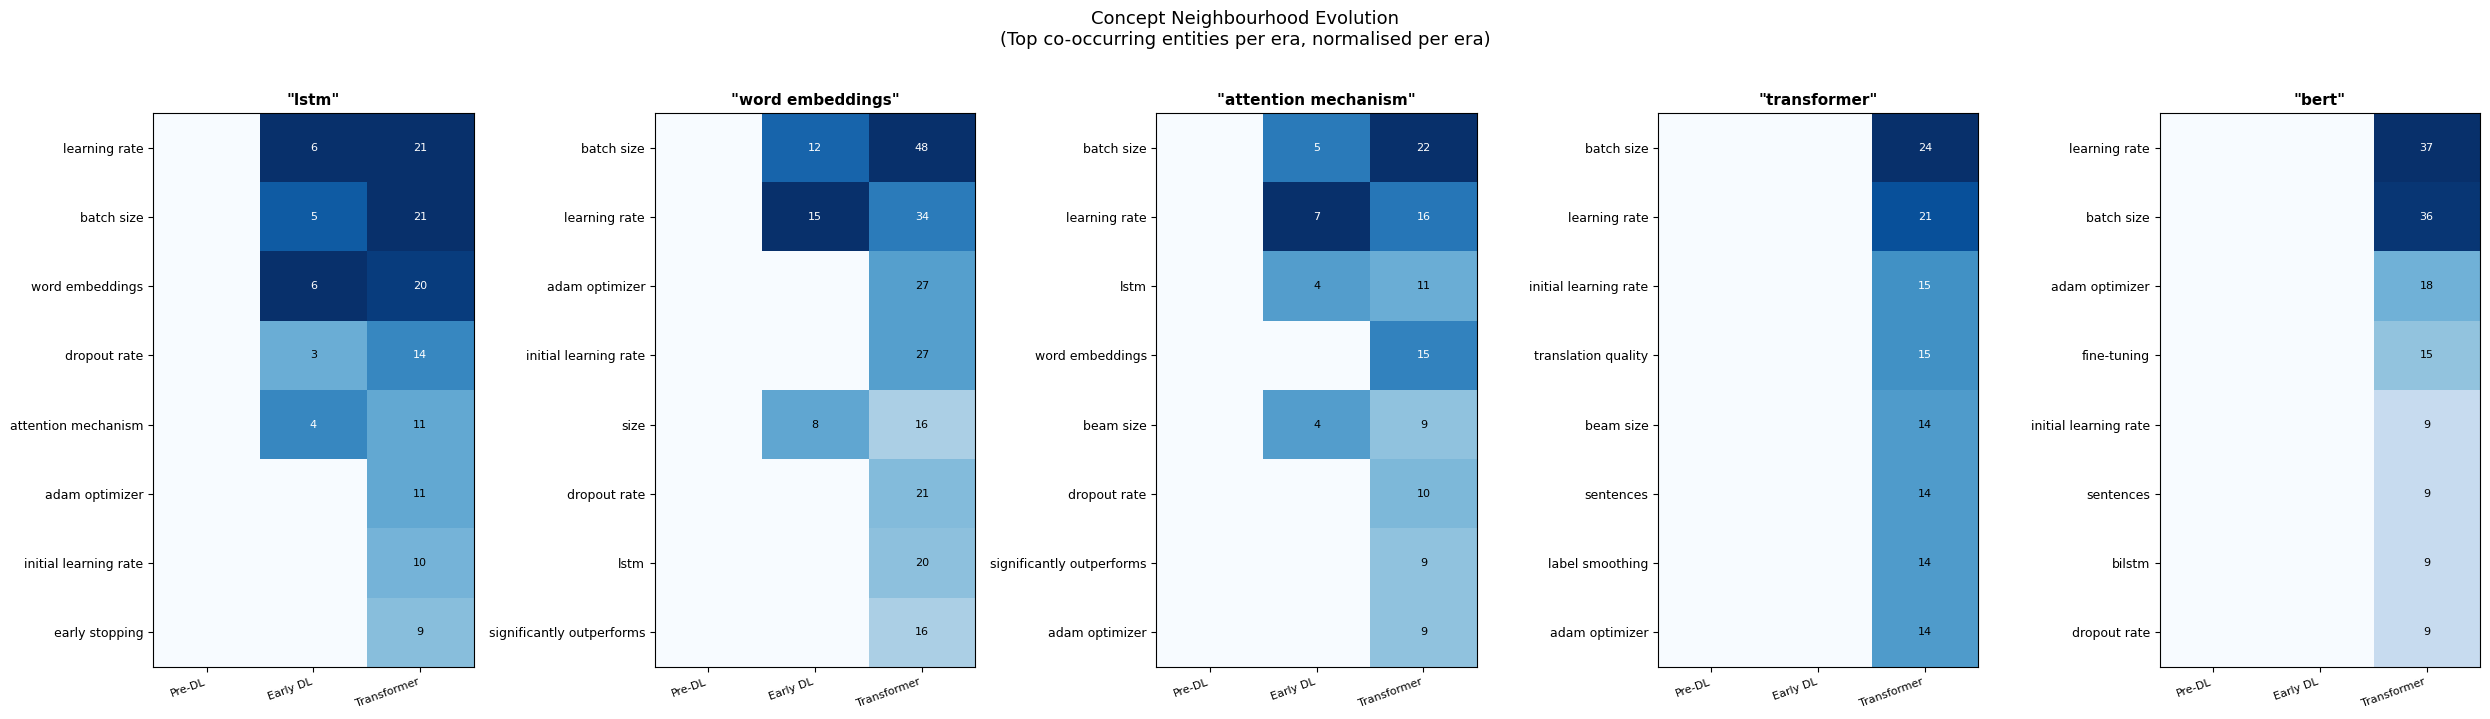

Saved neighbourhood_evolution_heatmap.png


In [7]:
era_names = list(ERAS.keys())
n_concepts = len(focus_ids)

fig, axes = plt.subplots(1, n_concepts, figsize=(5 * n_concepts, 7))
if n_concepts == 1:
    axes = [axes]

for ax, (concept, _) in zip(axes, focus_ids.items()):
    # Collect all co-entities across eras
    all_co = set()
    for era in era_names:
        all_co.update(neighbourhood_data[concept].get(era, {}).keys())
    
    if not all_co:
        ax.set_title(concept)
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue
    
    # Sort co-entities by total count across eras
    totals = {}
    for co in all_co:
        totals[co] = sum(
            neighbourhood_data[concept].get(era, {}).get(co, 0)
            for era in era_names
        )
    sorted_co = sorted(totals, key=totals.get, reverse=True)[:TOP_N_COENT]
    
    # Build matrix
    matrix = np.zeros((len(sorted_co), len(era_names)))
    for j, era in enumerate(era_names):
        era_data = neighbourhood_data[concept].get(era, {})
        for i, co in enumerate(sorted_co):
            matrix[i, j] = era_data.get(co, 0)
    
    # Normalize per era (column) for better visual contrast
    col_max = matrix.max(axis=0, keepdims=True)
    col_max[col_max == 0] = 1
    matrix_norm = matrix / col_max
    
    im = ax.imshow(matrix_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    
    ax.set_xticks(range(len(era_names)))
    ax.set_xticklabels([e.split('(')[0].strip() for e in era_names],
                       fontsize=8, rotation=20, ha='right')
    ax.set_yticks(range(len(sorted_co)))
    ax.set_yticklabels(sorted_co, fontsize=9)
    ax.set_title(f'"{concept}"', fontsize=11, fontweight='bold')
    
    # Annotate with raw counts
    for i in range(len(sorted_co)):
        for j in range(len(era_names)):
            val = int(matrix[i, j])
            if val > 0:
                text_color = 'white' if matrix_norm[i, j] > 0.6 else 'black'
                ax.text(j, i, str(val), ha='center', va='center',
                        fontsize=8, color=text_color)

fig.suptitle('Concept Neighbourhood Evolution\n(Top co-occurring entities per era, normalised per era)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/neighbourhood_evolution_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved neighbourhood_evolution_heatmap.png')

## 7. Visualisation 2 — Neighbourhood Shift (New / Persistent / Dropped)

For each concept, between consecutive eras, count how many co-entities are:
- **New** — appear in the later era but not the earlier
- **Persistent** — appear in both eras
- **Dropped** — appear in the earlier era but not the later

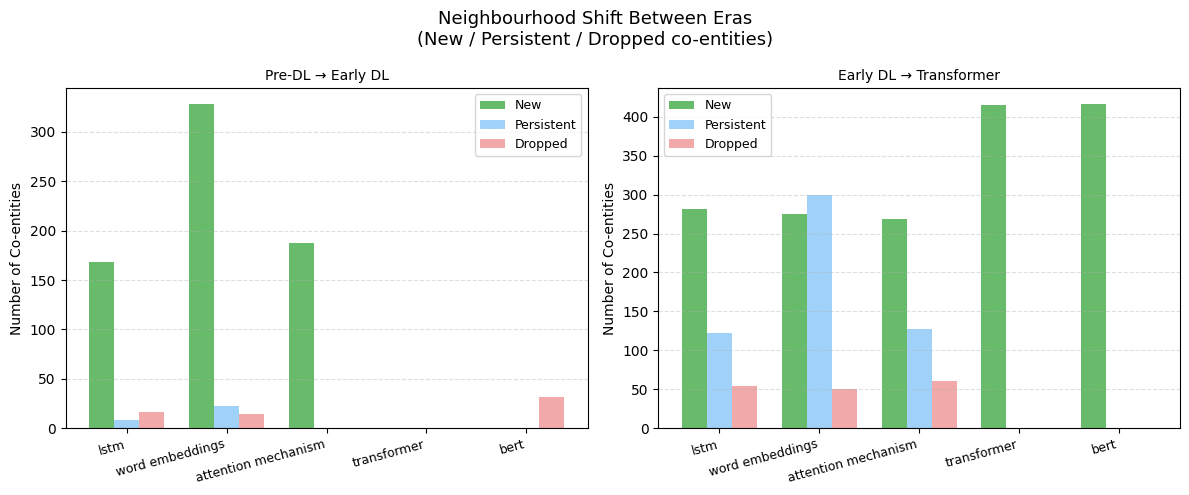

Saved neighbourhood_shift.png


In [8]:
# Use full neighbourhood (not just top N) for shift analysis
shift_records = []

for concept, cid in focus_ids.items():
    full_neighbourhood = {}
    for era_name, (y_start, y_end) in ERAS.items():
        era_edges = edges_clean[
            (edges_clean['year'] >= y_start) &
            (edges_clean['year'] <= y_end)
        ]
        concept_papers = era_edges[era_edges['target'] == cid]['source'].unique()
        if len(concept_papers) == 0:
            full_neighbourhood[era_name] = set()
            continue
        co = era_edges[
            era_edges['source'].isin(concept_papers) &
            era_edges['target'].isin(clean_ids) &
            (era_edges['target'] != cid)
        ]['target'].unique()
        full_neighbourhood[era_name] = set(co)
    
    # Consecutive era comparisons
    era_list = list(ERAS.keys())
    for i in range(len(era_list) - 1):
        e1, e2 = era_list[i], era_list[i+1]
        n1 = full_neighbourhood.get(e1, set())
        n2 = full_neighbourhood.get(e2, set())
        if not n1 and not n2:
            continue
        shift_records.append({
            'concept': concept,
            'transition': f'{e1.split("(")[0].strip()} →\n{e2.split("(")[0].strip()}',
            'new': len(n2 - n1),
            'persistent': len(n1 & n2),
            'dropped': len(n1 - n2),
        })

shift_df = pd.DataFrame(shift_records)

# Plot stacked bar per concept per transition
concepts = list(focus_ids.keys())
transitions = shift_df['transition'].unique()
n_trans = len(transitions)

fig, axes = plt.subplots(1, n_trans, figsize=(6 * n_trans, 5), sharey=False)
if n_trans == 1:
    axes = [axes]

colors = {'new': '#4CAF50', 'persistent': '#90CAF9', 'dropped': '#EF9A9A'}

for ax, trans in zip(axes, transitions):
    sub = shift_df[shift_df['transition'] == trans].set_index('concept')
    sub = sub.reindex(concepts).fillna(0)
    
    x = np.arange(len(concepts))
    width = 0.25
    
    for k, (col, color) in enumerate(colors.items()):
        ax.bar(x + k * width, sub[col], width, label=col.capitalize(), color=color, alpha=0.85)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(concepts, rotation=15, ha='right', fontsize=9)
    ax.set_title(trans.replace('\n', ' '), fontsize=10)
    ax.set_ylabel('Number of Co-entities', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Neighbourhood Shift Between Eras\n(New / Persistent / Dropped co-entities)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/neighbourhood_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved neighbourhood_shift.png')

## 8. Visualisation 3 — Concept Centrality Over Time

How the number of distinct co-entities (neighbourhood size) changes per year for each concept.

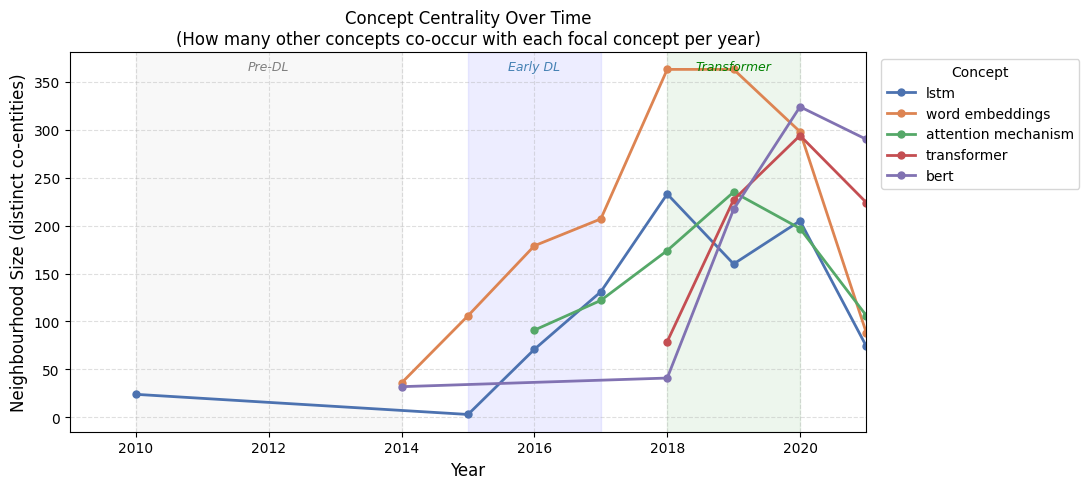

Saved concept_centrality.png


In [9]:
fig, ax = plt.subplots(figsize=(11, 5))

concept_colors = {
    'lstm'               : '#4C72B0',
    'word embeddings'    : '#DD8452',
    'attention mechanism': '#55A868',
    'transformer'        : '#C44E52',
    'bert'               : '#8172B2',
}

for concept in focus_ids:
    sub = centrality_df[centrality_df['concept'] == concept].sort_values('year')
    if sub.empty:
        continue
    ax.plot(sub['year'], sub['neighbourhood_size'],
            marker='o', linewidth=2, markersize=5,
            color=concept_colors.get(concept, 'grey'),
            label=concept)

# Era shading
ax.axvspan(2010, 2014, alpha=0.05, color='grey', label='_nolegend_')
ax.axvspan(2015, 2017, alpha=0.07, color='blue', label='_nolegend_')
ax.axvspan(2018, 2020, alpha=0.07, color='green', label='_nolegend_')

# Era labels
ax.text(2012, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 10,
        'Pre-DL', ha='center', fontsize=9, color='grey', style='italic')
ax.text(2016, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 10,
        'Early DL', ha='center', fontsize=9, color='steelblue', style='italic')
ax.text(2019, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 10,
        'Transformer', ha='center', fontsize=9, color='green', style='italic')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Neighbourhood Size (distinct co-entities)', fontsize=12)
ax.set_title('Concept Centrality Over Time\n(How many other concepts co-occur with each focal concept per year)',
             fontsize=12)
ax.legend(title='Concept', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
ax.grid(linestyle='--', alpha=0.4)
ax.set_xlim(2009, 2021)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/concept_centrality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved concept_centrality.png')

## 9. Summary

In [10]:
print('Concept Evolution Summary')
print()
for concept in focus_ids:
    print(f'{concept.upper()}')
    for era in era_names:
        top = neighbourhood_data[concept].get(era, {})
        if top:
            top3 = list(top.keys())[:3]
            print(f'  {era}: {top3}')
        else:
            print(f'  {era}: (no data)')
    print()

print('Outputs saved:')
print('  concept_neighbourhood_evolution.csv')
print('  concept_centrality_over_time.csv')
print('  neighbourhood_evolution_heatmap.png')
print('  neighbourhood_shift.png')
print('  concept_centrality.png')

Concept Evolution Summary

LSTM
  Pre-DL (≤2014): ['vector representation', 'best results', 'higher performance']
  Early DL (2015–17): ['learning rate', 'word embeddings', 'batch size']
  Transformer (2018–20): ['learning rate', 'batch size', 'word embeddings']

WORD EMBEDDINGS
  Pre-DL (≤2014): ['representations', 'text', 'documents']
  Early DL (2015–17): ['learning rate', 'batch size', 'test set']
  Transformer (2018–20): ['batch size', 'learning rate', 'initial learning rate']

ATTENTION MECHANISM
  Pre-DL (≤2014): (no data)
  Early DL (2015–17): ['learning rate', 'parameters', 'batch size']
  Transformer (2018–20): ['batch size', 'learning rate', 'word embeddings']

TRANSFORMER
  Pre-DL (≤2014): (no data)
  Early DL (2015–17): (no data)
  Transformer (2018–20): ['batch size', 'learning rate', 'initial learning rate']

BERT
  Pre-DL (≤2014): ['representations', 'text', 'documents']
  Early DL (2015–17): (no data)
  Transformer (2018–20): ['learning rate', 'batch size', 'adam optim